# 3. DAG 그래픽 모델

DAG는 교란(confounding), 중재(mediation), 충돌(collision)과 같은 복잡한 인과 구조를 직관적으로 이해하고, 변수 간의 통계적 독립성을 판단하는 데 매우 유용하게 사용된다.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm

from itertools import combinations
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import graphviz

In [2]:
COLORS = [
    '#00B0F0',
    '#FF0000'
]

## 1\. DAG 시각화

In [3]:
nodes = ['A', 'B', 'C', 'D']

In [4]:
# 그래프를 정의한다
graphs = {

    'DAG': {
        'graph': graphviz.Digraph(format='png'),
        'edges': ['AB', 'BC', 'AD', 'DC']
    },

    'DCG': {
        'graph': graphviz.Digraph(format='png'),
        'edges': ['AB', 'AD', 'BB', 'BC', 'DC', 'CA']
    },

    'Undirected': {
        'graph': graphviz.Graph(format='png'),
        'edges': ['AB', 'BC', 'AD', 'DC']
    },

    'Fully connected': {
        'graph': graphviz.Graph(format='png'),
        'edges': ['AB', 'AC', 'AD', 'BC', 'BD', 'CD']
    },

    'Partially connected': {
        'graph': graphviz.Graph(format='png'),
        'edges': ['AB', 'AC', 'BC']
    }
}


# 그래프를 반복하며 렌더링한다
for name, graph in graphs.items():

    [graph['graph'].node(n) for n in nodes]
    graph['graph'].edges(graph['edges'])

    graph['graph'].render(f'img/ch_04_graph_{name}')

### 인접 행렬 (Adjacency matrices)

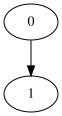

In [5]:
graph = graphviz.Digraph(format='png')

nodes = ['0', '1']

edges = ['01']

[graph.node(n) for n in nodes]
graph.edges(edges)

graph.render(f'img/ch_04_graph_adj_00')

graph

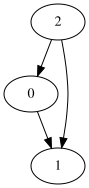

In [14]:
graph = graphviz.Digraph(format='png')

nodes = ['0', '1', '2']

edges = ['01', '21', '20']

[graph.node(n) for n in nodes]
graph.edges(edges)

graph.render(f'img/ch_04_graph_adj_01')

graph

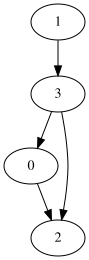

In [15]:
graph = graphviz.Digraph(format='png')

nodes = ['0', '1', '2', '3']

edges = ['02', '13', '32', '30']

[graph.node(n) for n in nodes]
graph.edges(edges)

graph.render(f'img/ch_04_graph_adj_02')

graph

## 2\. 파이썬에서의 그래프

### GML

**GML**은 그래프 모델링 언어(Graph Modelling Language)의 약자로, 그래프 구조를 텍스트 형식으로 기술하기 위한 표준 파일 형식이다. 사람이 쉽게 읽고 쓸 수 있는 구조로 되어 있어 그래프 데이터를 공유하고 저장하는 데 널리 사용된다.

GML 문법에 대한 더 자세한 정보는 다음 링크에서 확인할 수 있다: [https://github.com/GunterMueller/UNI\_PASSAU\_FMI\_Graph\_Drawing/blob/master/GML/gml-technical-report.pdf](https://github.com/GunterMueller/UNI_PASSAU_FMI_Graph_Drawing/blob/master/GML/gml-technical-report.pdf)

In [16]:
import networkx as nx

### 엣지 리스트

엣지 리스트(Edge list)는 그래프를 표현하는 가장 간단한 방법 중 하나로, 연결된 노드 쌍을 목록 형태로 나열하여 그래프의 구조를 정의한다.

In [17]:
# 그래프를 정의한다
sample_gml = """graph [
directed 1

node [
    id 0
    label "0"
    ]

node [
    id 1
    label "1"
    ]

node [
    id 2
    label "2"
    ]


edge [
    source 0
    target 1
    ]

edge [
    source 2
    target 1
    ]
]

    """

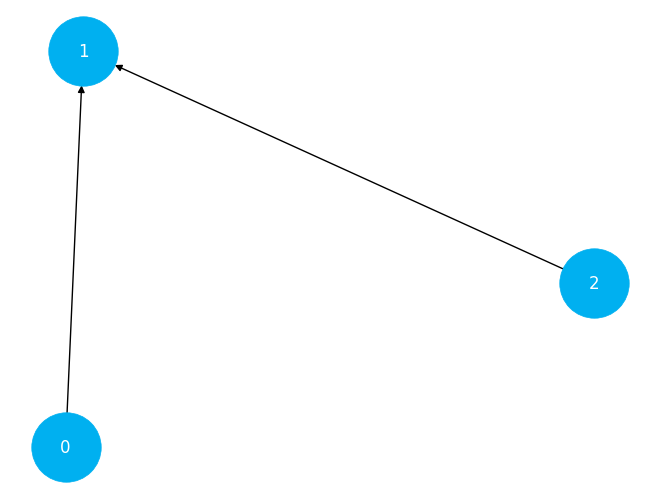

In [18]:
# Get the graph
graph = nx.parse_gml(sample_gml)

# Plot
nx.draw(
    G=graph,
    with_labels=True,
    node_size=2500,
    node_color=COLORS[0],
    font_color='white'
)

### 인접 행렬

인접 행렬(Adjacency matrix)은 `networkx`에서 그래프를 생성하는 또 다른 방법이다. `numpy` 배열로 표현된 인접 행렬을 직접 사용하여 그래프 객체를 만들 수 있어, 수치 데이터를 다룰 때 매우 편리하다.

In [19]:
# 행렬을 정의한다
adj_matrix = np.array([
    [0, 1, 0, 1, 0, 1],
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0],
    [0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0],
])

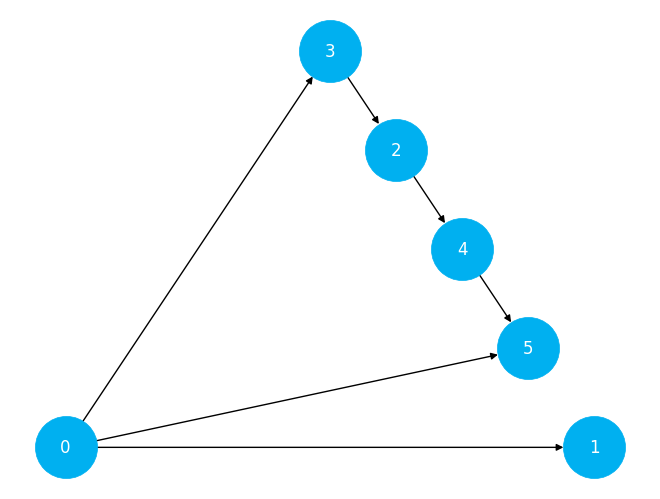

In [20]:
# 그래프를 가져온다
graph = nx.from_numpy_array(adj_matrix, create_using=nx.DiGraph)

# 플롯
nx.draw(
    G=graph,
    with_labels=True,
    node_size=2000,
    node_color=COLORS[0],
    font_color='white',
    pos=nx.planar_layout(graph)
)

## 3\. 통계적 독립과 그래픽적 독립

1.  **체인(Chain)**: `A -> B -> C`. 이 경우, 중간 노드 `B`를 통제(조건부)하면 `A`와 `C` 사이의 경로가 차단된다.
2.  **분기(Fork)**: `A <- B -> C`. 공통 원인 `B`를 통제하면 `A`와 `C` 사이의 경로가 차단된다.
3.  **충돌(Collider)**: `A -> B <- C`. `A`와 `C`가 `B`의 원인일 때, `B`를 충돌 변수라고 한다.

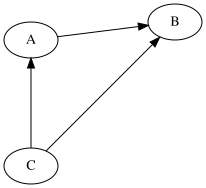

In [21]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['A', 'B', 'C']
positions = ['0,2.75!', '2,3!', '0,1!']

edges = ['AB', 'CB', 'CA']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]
graph.edges(edges)

graph.render(f'img/ch_05_markov_01')

graph

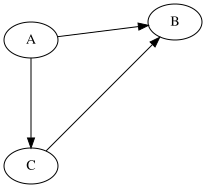

In [22]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['A', 'B', 'C']
positions = ['0,2.75!', '2,3!', '0,1!']

edges = ['AB', 'CB', 'AC']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]
graph.edges(edges)

graph.render(f'img/ch_05_markov_02')

graph

In [24]:
NOISE_LEVEL = .2
N_SAMPLES = 1000

### 3.1. 체인: `A -> B -> C`

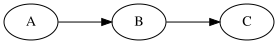

In [25]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['A', 'B', 'C']
positions = ['0,0!', '1.5,0!', '3,0!']

edges = ['AB', 'BC']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]
graph.edges(edges)

graph.render(f'img/ch_05_chain_00')

graph

In [26]:
# 데이터를 생성한다
a = np.random.randn(N_SAMPLES)
b = a + NOISE_LEVEL*np.random.randn(N_SAMPLES)
c = b + NOISE_LEVEL*np.random.randn(N_SAMPLES)

# 조합을 가져온다
combs = list(combinations([('a', a), ('b', b), ('c', c)], 2))

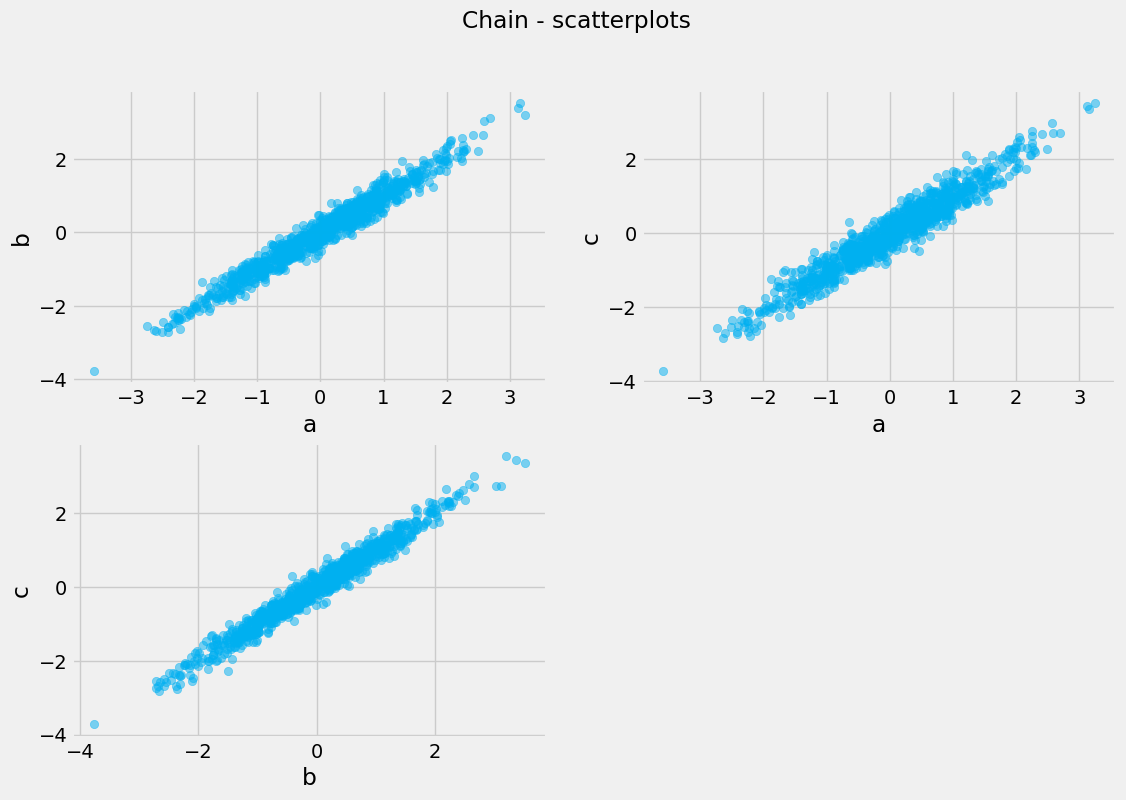

In [27]:
# Plot
plt.figure(figsize=(12, 8))

for i, comb in enumerate(combs):
    key_1, key_2 = comb[0][0], comb[1][0]


    plt.subplot(2, 2, i + 1)
    plt.scatter(comb[0][1], comb[1][1], alpha=.5, color=COLORS[0])
    plt.xlabel(key_1)
    plt.ylabel(key_2)

plt.suptitle('Chain - scatterplots')
plt.show()

In [28]:
X = pd.DataFrame(np.vstack([a, b]).T, columns=['A', 'B'])
X = sm.add_constant(X, prepend=True)

model = sm.OLS(c, X)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                 1.459e+04
Date:                Wed, 25 Jun 2025   Prob (F-statistic):               0.00
Time:                        17:41:54   Log-Likelihood:                 216.94
No. Observations:                1000   AIC:                            -427.9
Df Residuals:                     997   BIC:                            -413.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0004      0.006     -0.062      0.9

### 3.2. 충돌: `A -> B <- C`

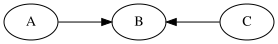

In [29]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['A', 'B', 'C']
positions = ['0,0!', '1.5,0!', '3,0!']

edges = ['AB', 'CB']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]
graph.edges(edges)

graph.render(f'img/ch_05_collider_00')

graph

In [30]:
# 데이터를 생성한다
a = np.random.randn(N_SAMPLES)
c = np.random.randn(N_SAMPLES)
b = a + c + NOISE_LEVEL*np.random.randn(N_SAMPLES)

# 조합을 가져온다
combs = list(combinations([('a', a), ('b', b), ('c', c)], 2))

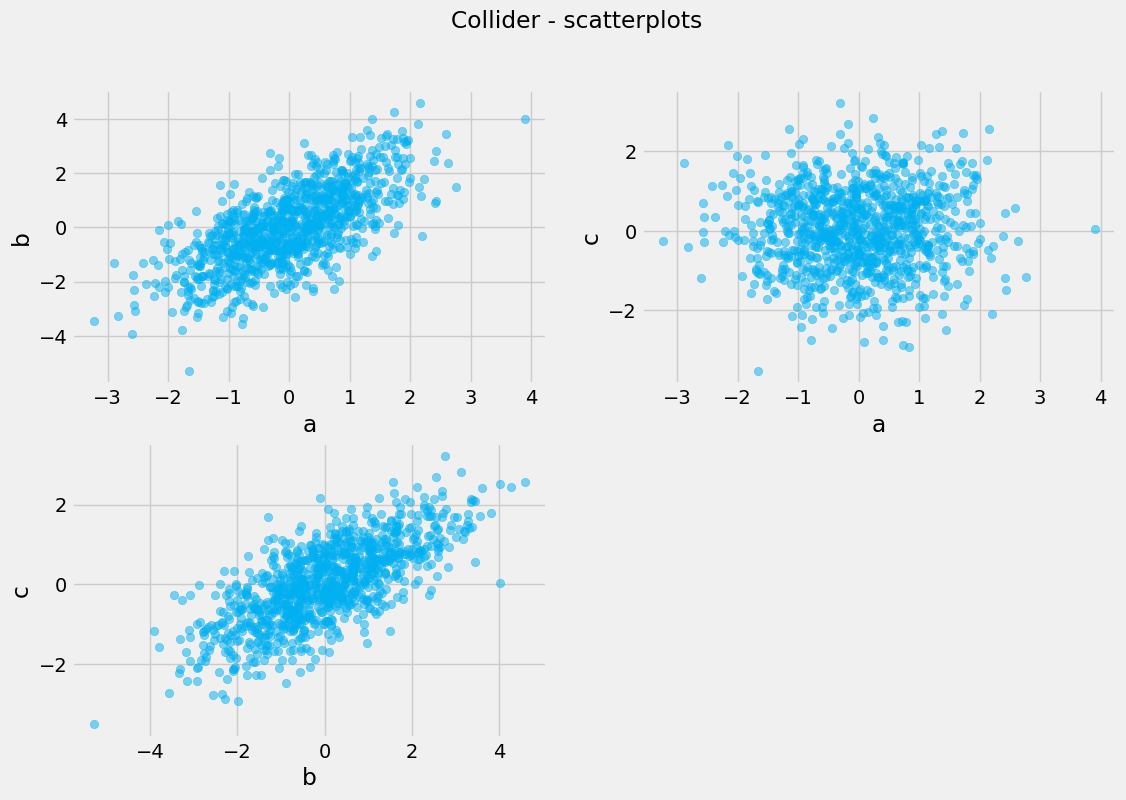

In [31]:
# Plot
plt.figure(figsize=(12, 8))

for i, comb in enumerate(combs):
    key_1, key_2 = comb[0][0], comb[1][0]


    plt.subplot(2, 2, i + 1)
    plt.scatter(comb[0][1], comb[1][1], alpha=.5, color=COLORS[0])
    plt.xlabel(key_1)
    plt.ylabel(key_2)

plt.suptitle('Collider - scatterplots')
plt.show()

In [32]:
X = pd.DataFrame(np.vstack([a, b]).T, columns=['A', 'B'])
X = sm.add_constant(X, prepend=True)

model = sm.OLS(c, X)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                 1.368e+04
Date:                Wed, 25 Jun 2025   Prob (F-statistic):               0.00
Time:                        17:42:10   Log-Likelihood:                 238.78
No. Observations:                1000   AIC:                            -471.6
Df Residuals:                     997   BIC:                            -456.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0005      0.006     -0.089      0.9